<a href="https://colab.research.google.com/github/debabratahazra/scaler_code/blob/master/Intro_to_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (20, 6)

In [ ]:
!gdown 1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg

Downloading...
From: https://drive.google.com/uc?id=1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg
To: /content/mobilesales.xlsx
100% 13.7k/13.7k [00:00<00:00, 38.4MB/s]


In [ ]:
mobile_sales = pd.read_excel('/content/mobilesales.xlsx')
mobile_sales.head()

,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [ ]:
mobile_sales.dtypes

,0
DATE,datetime64[ns]
Sales,float64


In [ ]:
mobile_sales.shape

(217, 2)

In [ ]:
mobile_sales.nunique()

,0
DATE,217
Sales,193


In [ ]:
mobile_sales

,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0
...,...,...
212,2018-09-01,13838.0
213,2018-10-01,15351.0
214,2018-11-01,15615.0
215,2018-12-01,16941.0


In [ ]:
mobile_sales["DATE"].describe()

,DATE
count,217
mean,2009-12-31 04:25:26.267281152
min,2001-01-01 00:00:00
25%,2005-07-01 00:00:00
50%,2010-01-01 00:00:00
75%,2014-07-01 00:00:00
max,2019-01-01 00:00:00


In [ ]:
mobile_sales.set_index('DATE', inplace=True)
mobile_sales

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0
...,...
2018-09-01,13838.0
2018-10-01,15351.0
2018-11-01,15615.0


<Axes: xlabel='DATE'>

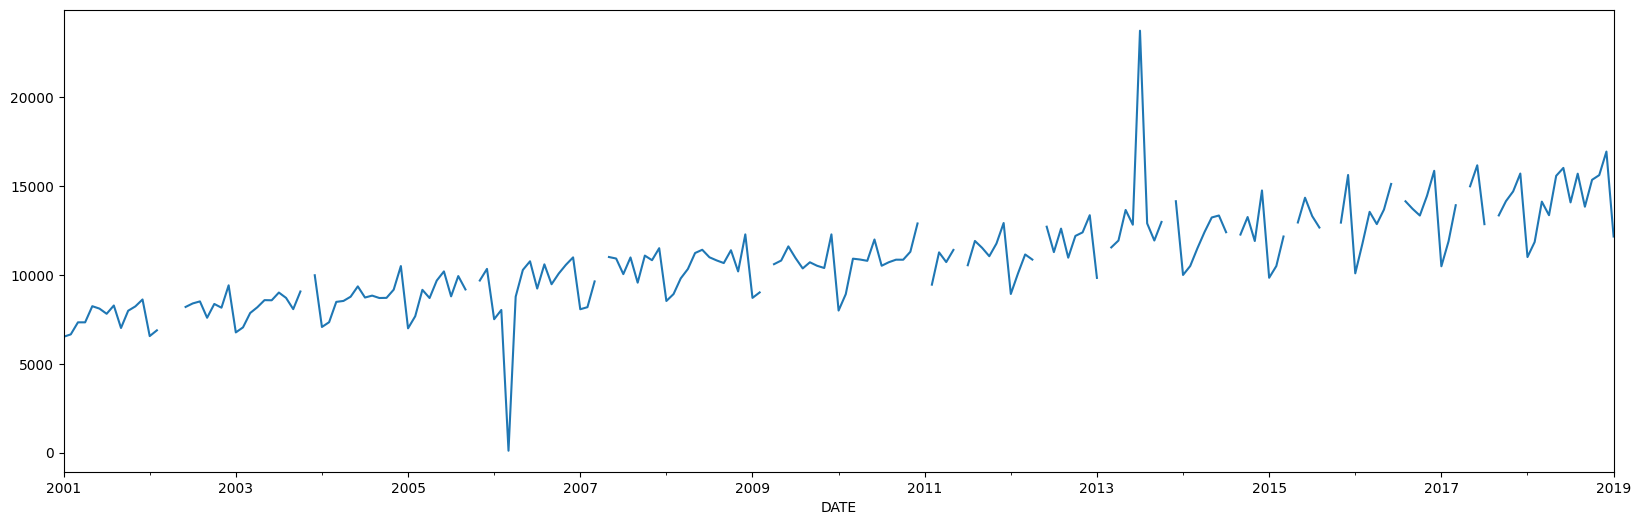

In [ ]:
mobile_sales.Sales.plot()

In [ ]:
mobile_sales.isna().sum()

,0
Sales,19


In [ ]:
mobile_sales.loc[mobile_sales.Sales.isna()]

,Sales
DATE,
2002-03-01,NaN
2002-04-01,NaN
2002-05-01,NaN
2003-11-01,NaN
2005-10-01,NaN
2007-04-01,NaN
2009-03-01,NaN
2011-01-01,NaN
2011-06-01,NaN


In [ ]:
mobile_sales.Sales.mean()

np.float64(10842.757575757576)

In [ ]:
mobile_sales.Sales.median()

10745.0

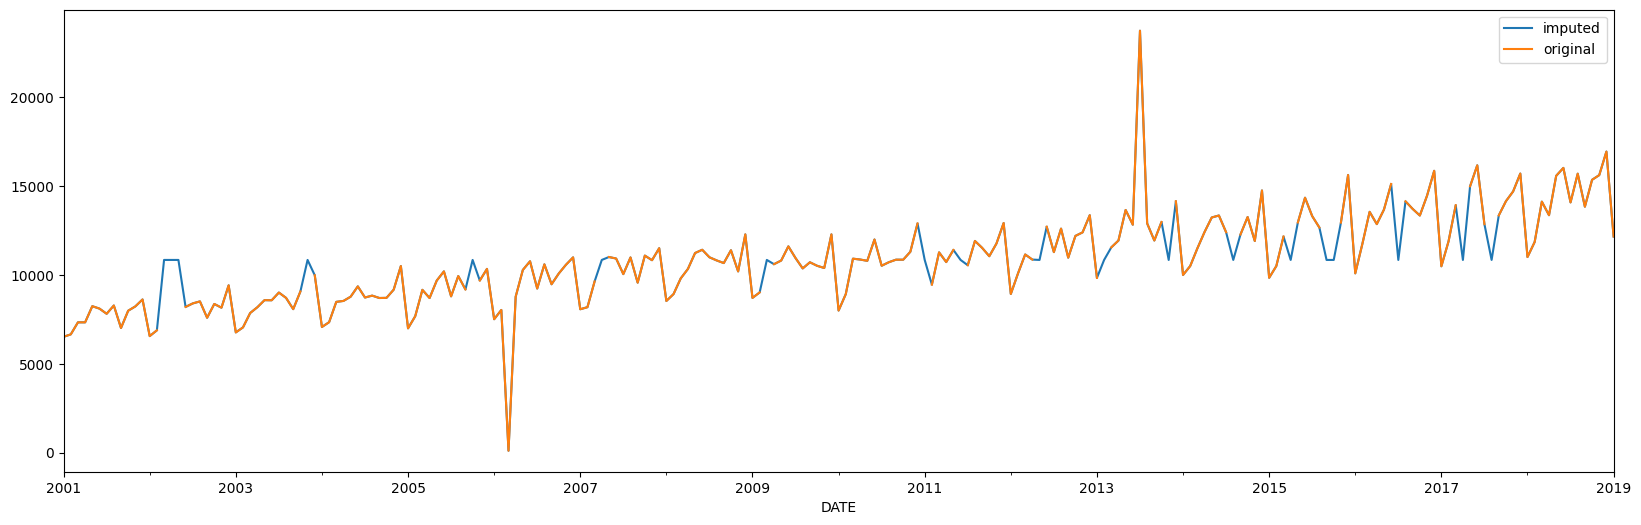

In [ ]:
mobile_sales.Sales.fillna(mobile_sales.Sales.mean()).plot(label='imputed')
mobile_sales.Sales.plot(label='original')
plt.legend()

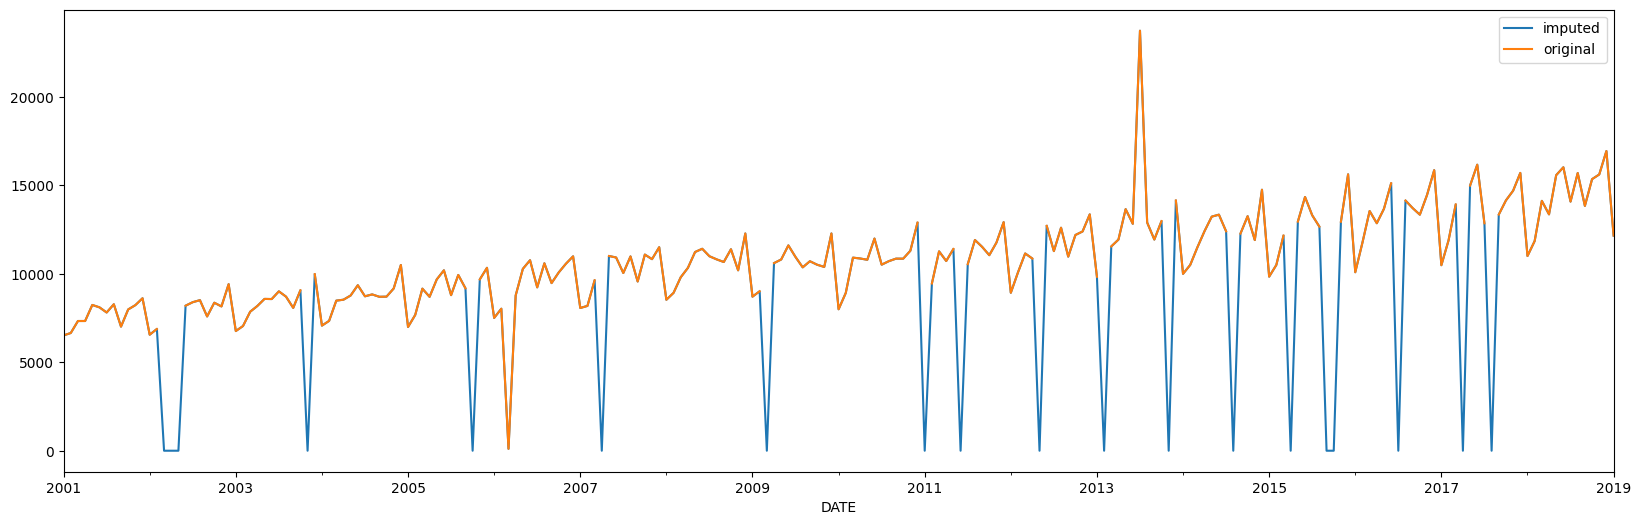

In [ ]:
mobile_sales.Sales.fillna(0).plot(label='imputed')
mobile_sales.Sales.plot(label='original')
plt.legend()

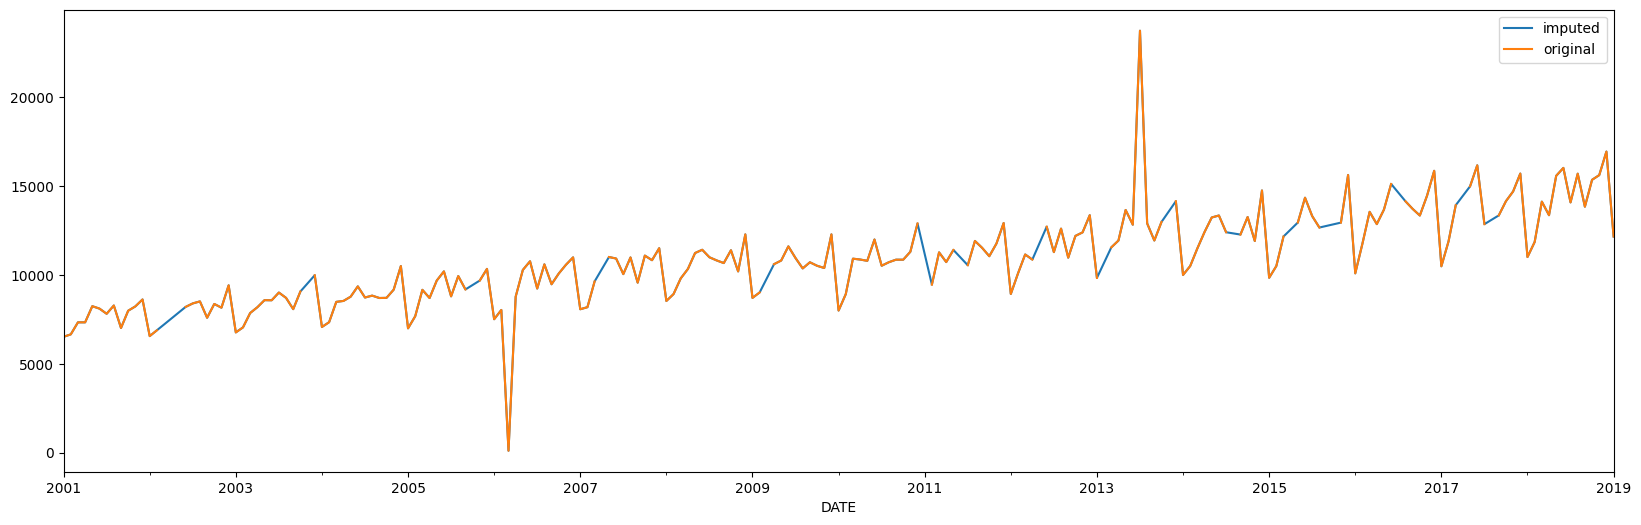

In [ ]:
mobile_sales.Sales.interpolate(method='linear').plot(label='imputed')
mobile_sales.Sales.plot(label='original')
plt.legend()


In [ ]:
mobile_sales.Sales = mobile_sales.Sales.interpolate(method='linear')

<Axes: xlabel='DATE'>

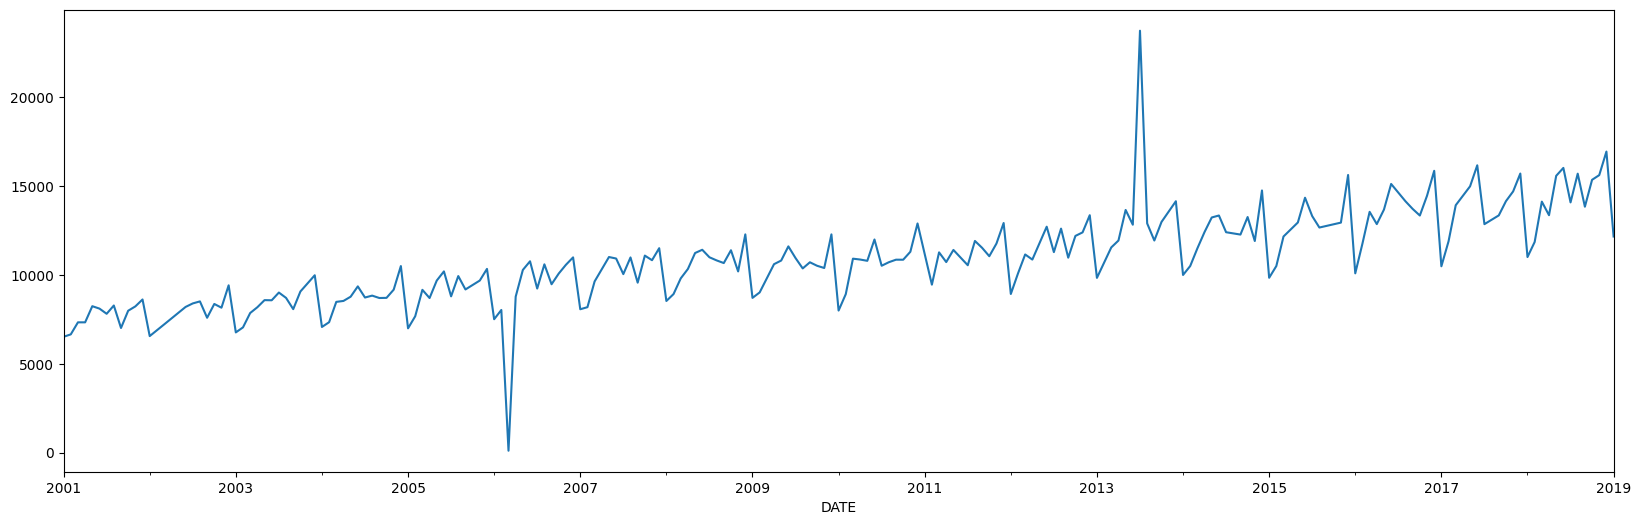

In [ ]:
mobile_sales.Sales.plot(label='original')


[]

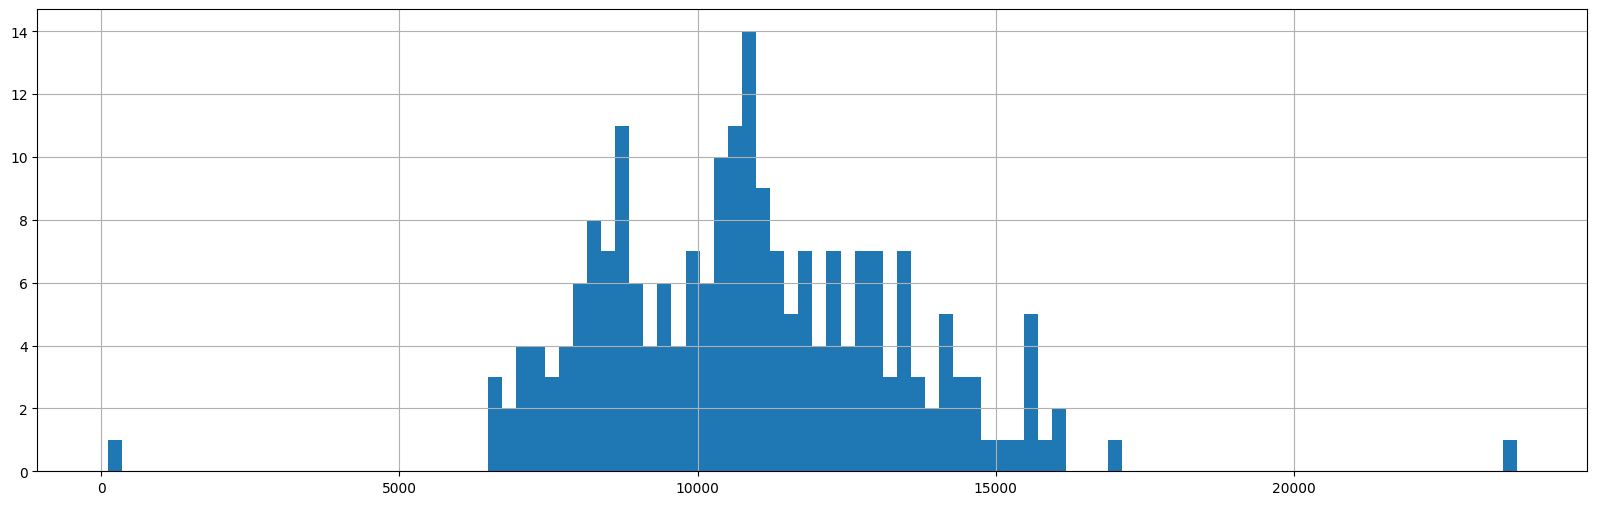

In [ ]:
mobile_sales.Sales.hist(bins=100).plot()

In [ ]:
mobile_sales.Sales.quantile(0.95)

np.float64(15164.599999999997)

In [ ]:
mobile_sales.Sales.quantile(0.05)

np.float64(7307.8)

<Axes: xlabel='DATE'>

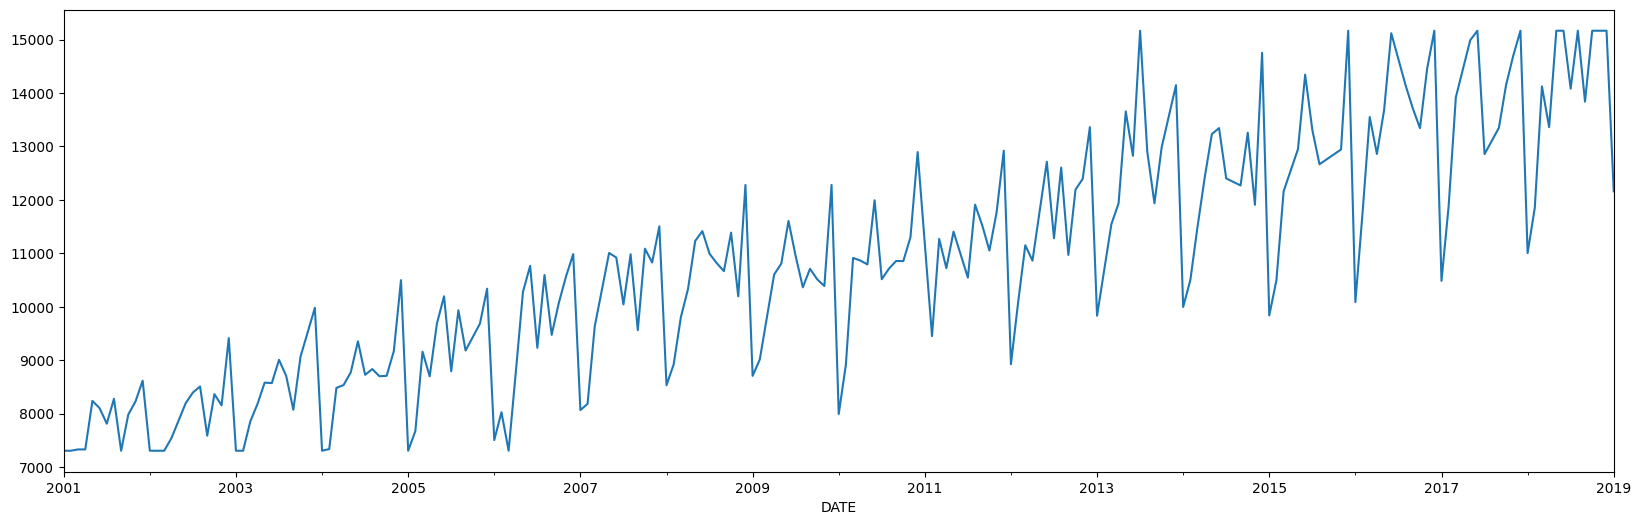

In [ ]:
mobile_sales.Sales.clip(upper=mobile_sales.Sales.quantile(0.95), lower=mobile_sales.Sales.quantile(0.05)).plot()

In [ ]:
#mobile_sales["Sales_clipped"] = mobile_sales.Sales.clip(upper=mobile_sales.Sales.quantile(0.95), lower=mobile_sales.Sales.quantile(0.05))

In [ ]:
mobile_sales

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0
...,...
2018-09-01,13838.0
2018-10-01,15351.0
2018-11-01,15615.0


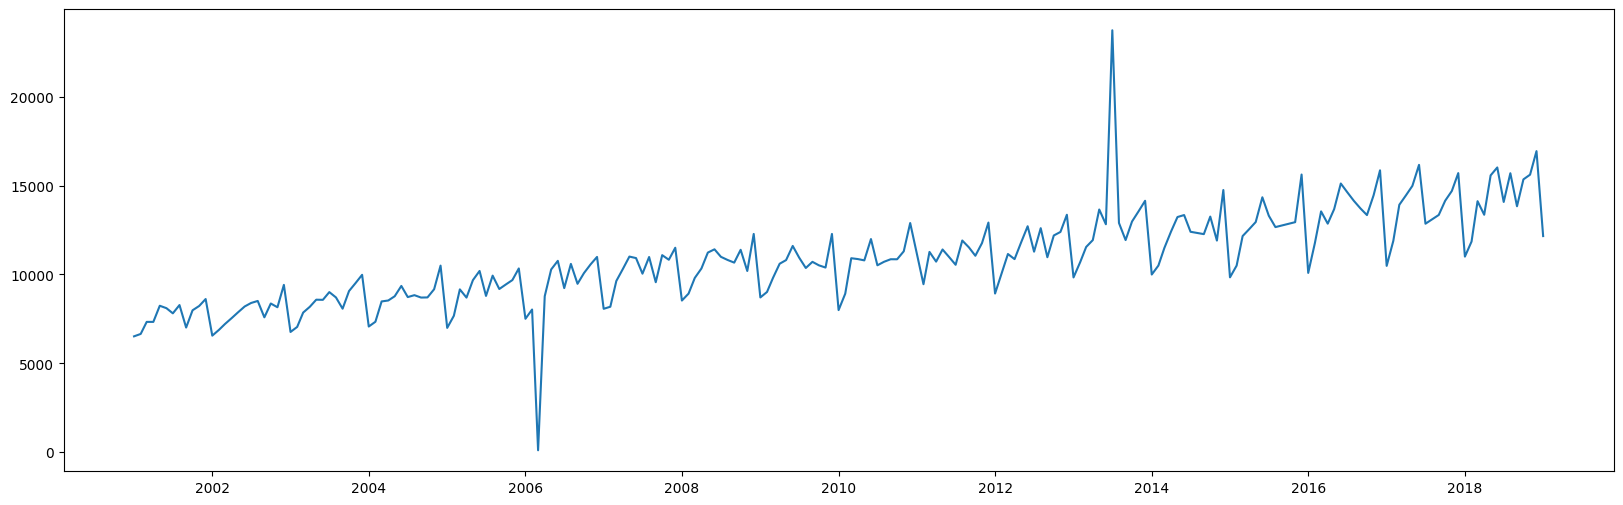

In [ ]:
plt.plot(mobile_sales["Sales"])


In [ ]:
#plt.plot(mobile_sales["Sales_clipped"])

In [ ]:
mobile_sales.Sales = mobile_sales.Sales.clip(upper=mobile_sales.Sales.quantile(0.98), lower=mobile_sales.Sales.quantile(0.02))

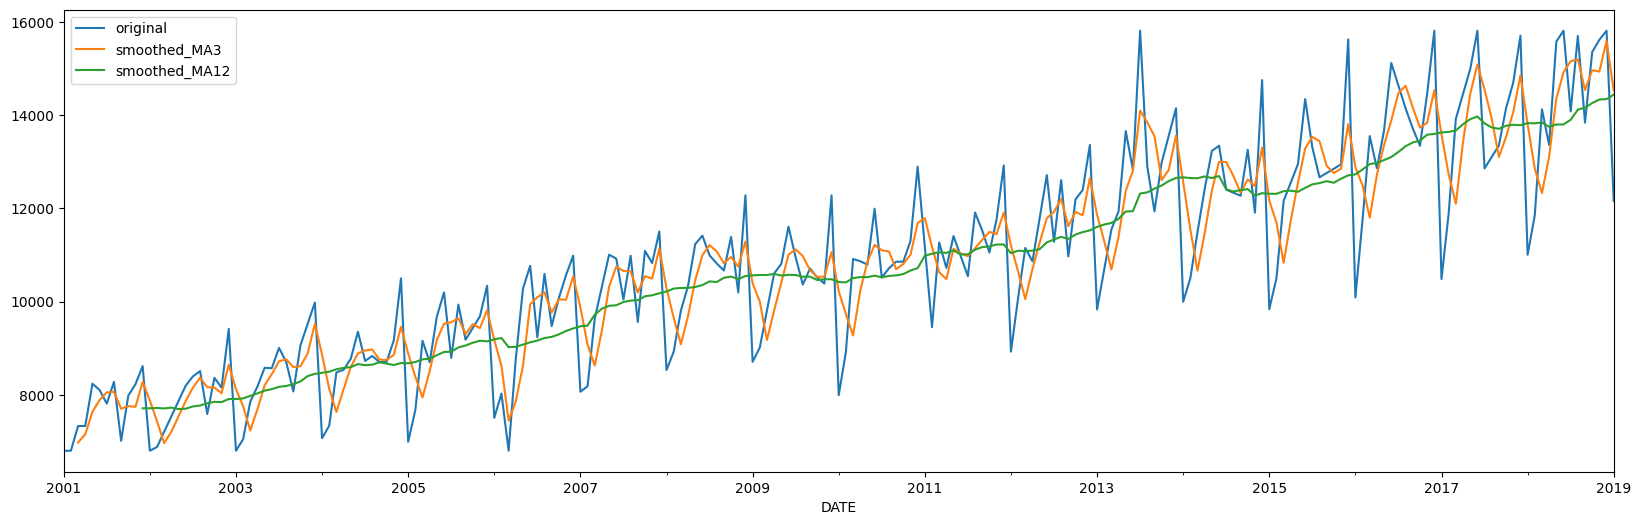

In [ ]:
# Plot original data
mobile_sales.Sales.plot(label='original')

# Plot data after implementing Moving Averages
mobile_sales.Sales.rolling(3, center=False).mean().plot(label='smoothed_MA3')
mobile_sales.Sales.rolling(12, center=False).mean().plot(label='smoothed_MA12')
plt.legend()

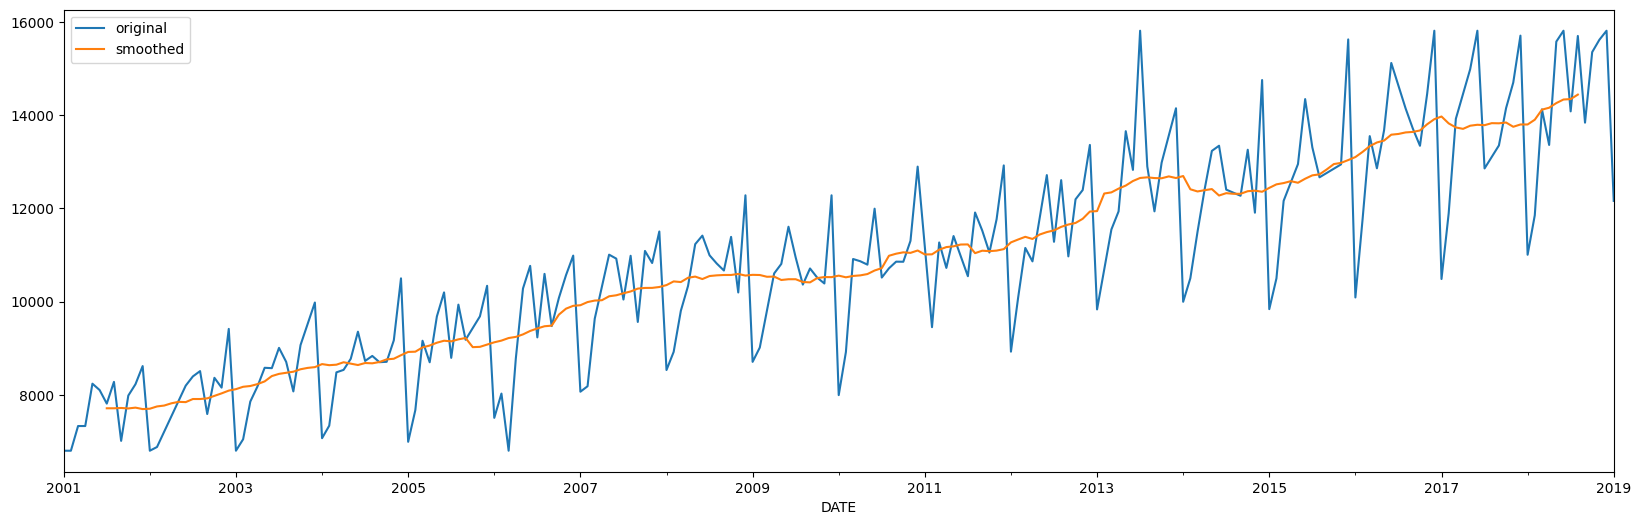

In [ ]:
mobile_sales.Sales.plot(label='original')
mobile_sales.Sales.rolling(12, center=True).mean().plot(label='smoothed')
plt.legend()

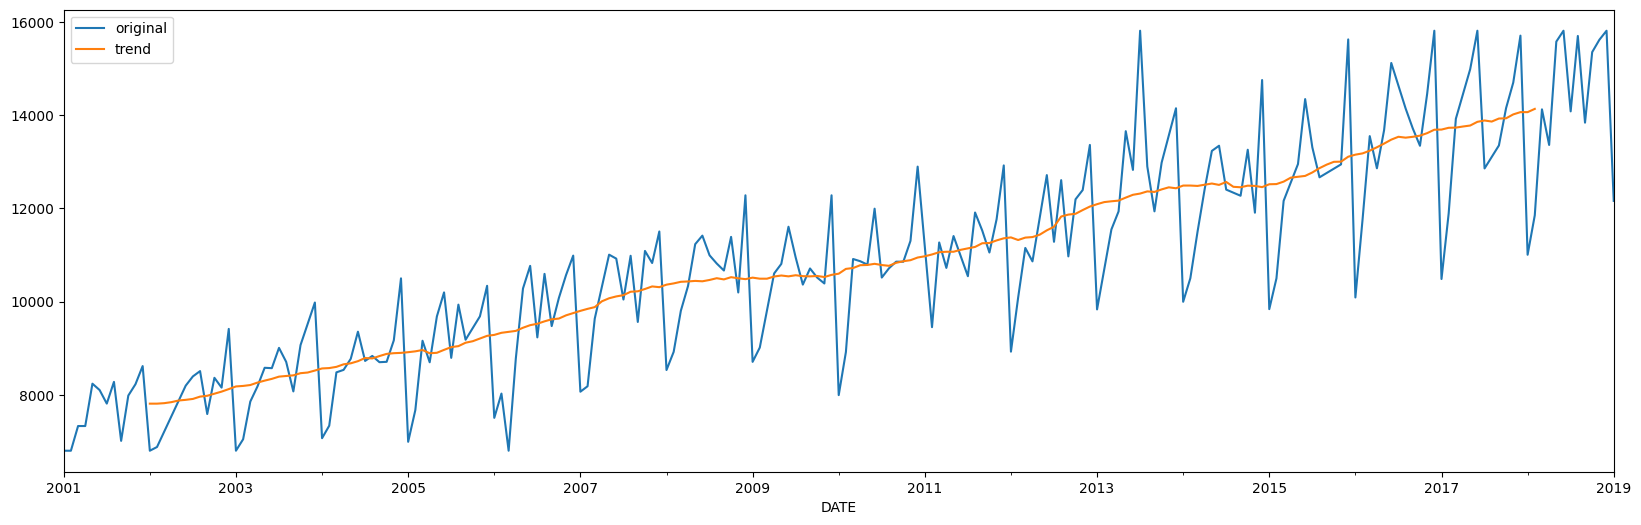

In [ ]:
mobile_sales.Sales.plot(label='original')
mobile_sales.Sales.rolling(24, center=True).mean().plot(label='trend')

plt.legend()

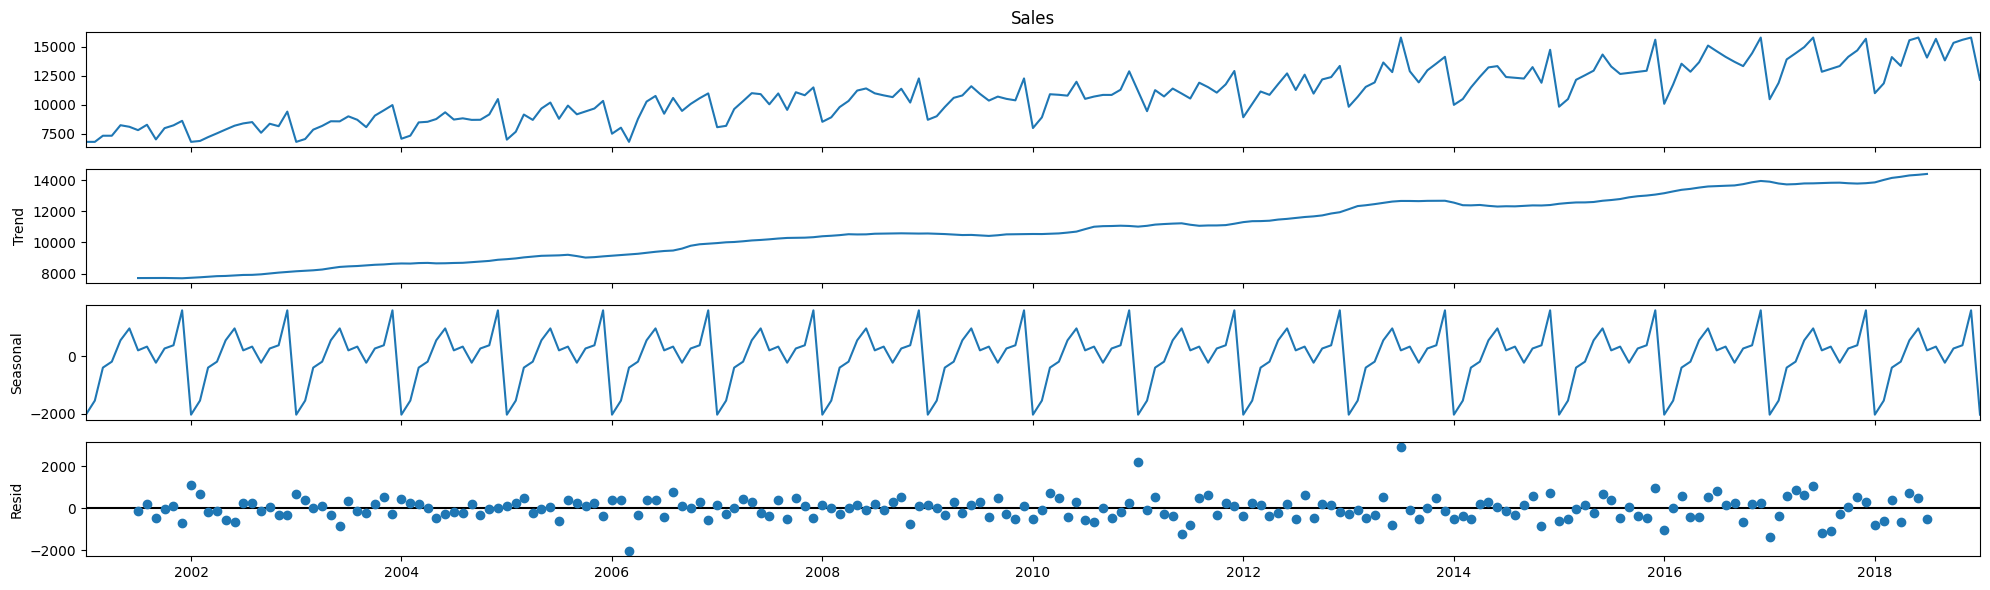

In [ ]:
import statsmodels.api as sm

model = sm.tsa.seasonal_decompose(mobile_sales.Sales, model='additive')
model.plot();

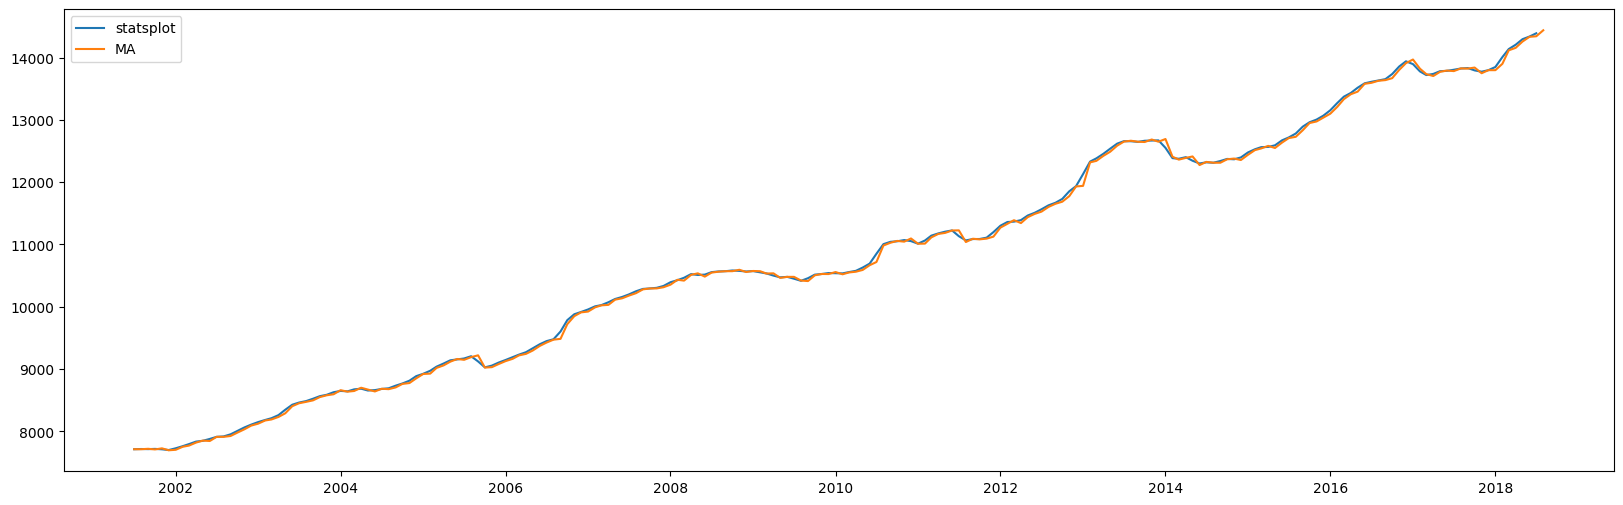

In [ ]:
trend = mobile_sales.rolling(12, center=True).mean()
plt.plot(model.trend,label="statsplot")
plt.plot(trend["Sales"],label="MA")
plt.legend()

In [ ]:
model.seasonal.head(20)

,seasonal
DATE,
2001-01-01,-2032.037280
2001-02-01,-1541.160123
2001-03-01,-390.864633
2001-04-01,-182.669927
2001-05-01,562.026152
2001-06-01,977.197230
2001-07-01,211.346549
2001-08-01,342.453504
2001-09-01,-218.812574


<Axes: xlabel='DATE'>

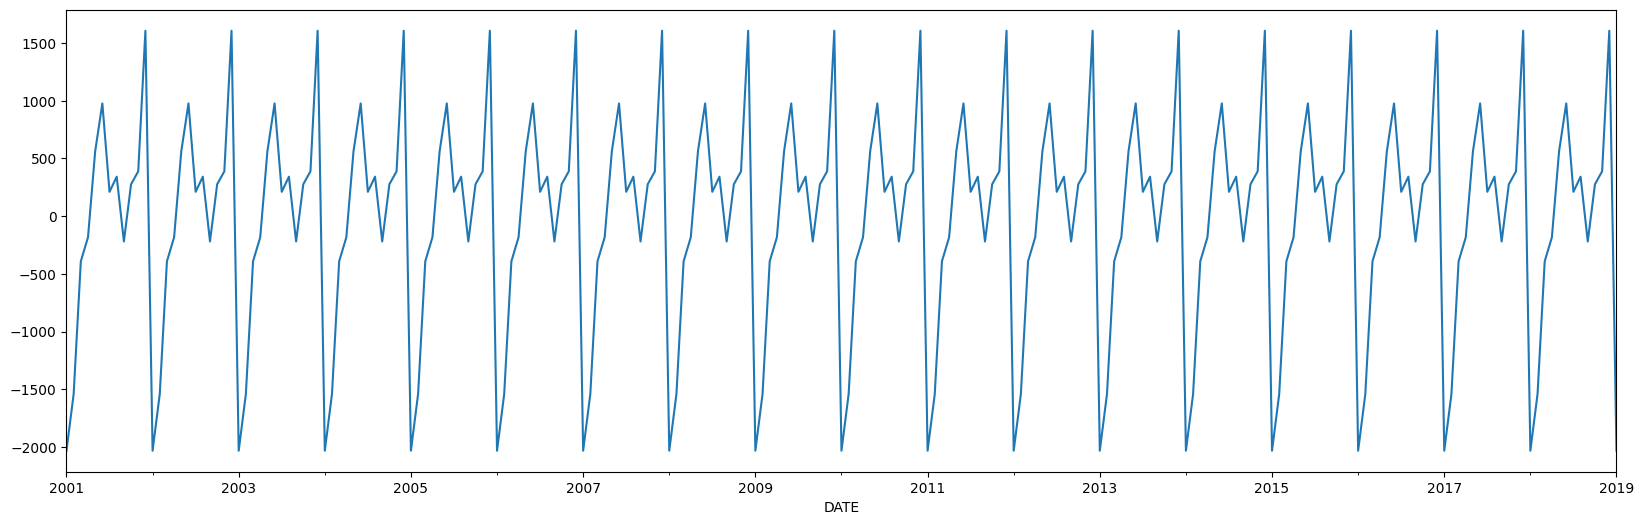

In [ ]:
model.seasonal.plot()

In [ ]:
model.resid.plot(kind="hist",bins=100)

In [ ]:
model.resid.mean()

In [ ]:
train_max_date = mobile_sales.index[-12]
train_max_date

In [ ]:
train_max_date = mobile_sales.index[-12]
train_x = mobile_sales.loc[mobile_sales.index < mobile_sales.index[-12]].copy()
test_x = mobile_sales.loc[mobile_sales.index >= mobile_sales.index[-12]].copy()

In [ ]:
mobile_sales

In [ ]:
train_x

In [ ]:
test_x

,Sales
DATE,
2018-02-01,11852.0
2018-03-01,14123.0
2018-04-01,13360.0
2018-05-01,15576.0
2018-06-01,15809.4
2018-07-01,14080.0
2018-08-01,15697.0
2018-09-01,13838.0
2018-10-01,15351.0


In [ ]:
train_x

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2017-09-01,13349.00
2017-10-01,14150.00
2017-11-01,14698.00


In [ ]:
train_x['Sales'].mean()

np.float64(10653.201951219511)

In [ ]:
test_x['pred'] = train_x['Sales'].mean()


In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,10653.201951
2018-03-01,14123.0,10653.201951
2018-04-01,13360.0,10653.201951
2018-05-01,15576.0,10653.201951
2018-06-01,15809.4,10653.201951
2018-07-01,14080.0,10653.201951
2018-08-01,15697.0,10653.201951
2018-09-01,13838.0,10653.201951
2018-10-01,15351.0,10653.201951


In [ ]:
train_x

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2017-09-01,13349.00
2017-10-01,14150.00
2017-11-01,14698.00


In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,10653.201951
2018-03-01,14123.0,10653.201951
2018-04-01,13360.0,10653.201951
2018-05-01,15576.0,10653.201951
2018-06-01,15809.4,10653.201951
2018-07-01,14080.0,10653.201951
2018-08-01,15697.0,10653.201951
2018-09-01,13838.0,10653.201951
2018-10-01,15351.0,10653.201951


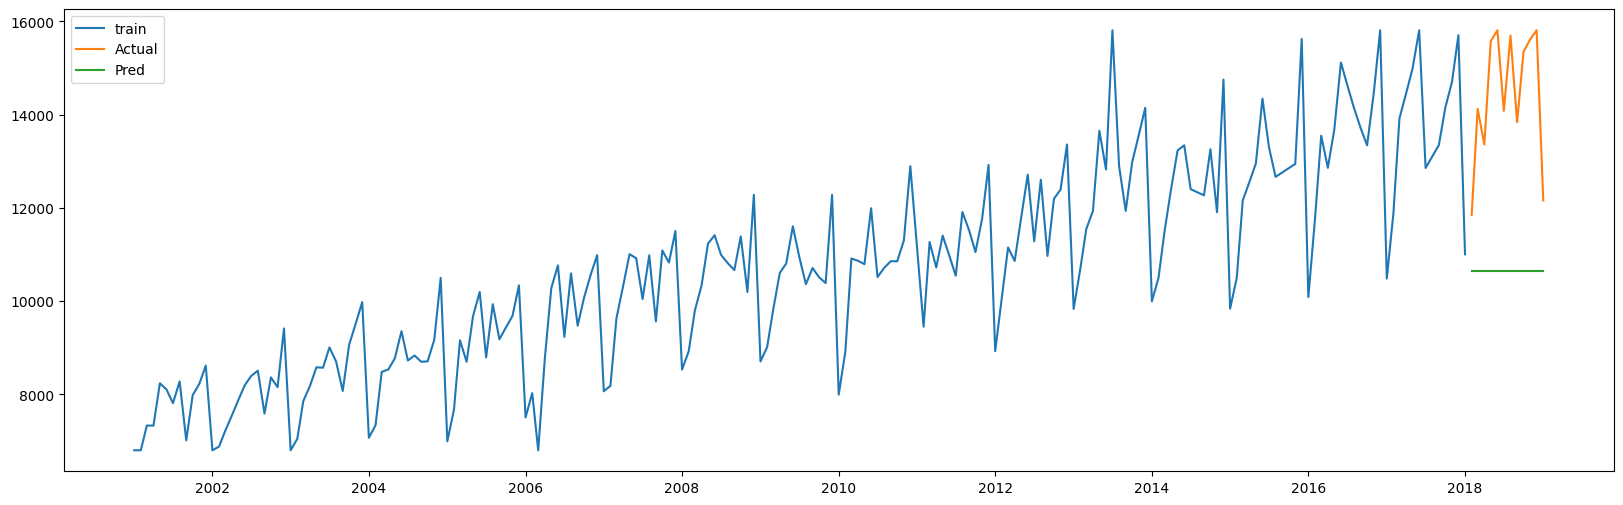

In [ ]:
plt.plot(train_x["Sales"],label="train")
plt.plot(test_x["Sales"],label="Actual")
plt.plot(test_x["pred"],label="Pred")
plt.legend()

In [ ]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

In [ ]:
performance(test_x['Sales'], test_x['pred'])

MAE : 3786.031
RMSE : 4025.906
MAPE: 0.255


In [ ]:
train_x['Sales'][-1]

/tmp/ipython-input-79-3296023292.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  train_x['Sales'][-1]


np.float64(11005.0)

In [ ]:
test_x['pred'] = train_x['Sales'][-1]
test_x

/tmp/ipython-input-80-2496189371.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = train_x['Sales'][-1]


,Sales,pred
DATE,,
2018-02-01,11852.0,11005.0
2018-03-01,14123.0,11005.0
2018-04-01,13360.0,11005.0
2018-05-01,15576.0,11005.0
2018-06-01,15809.4,11005.0
2018-07-01,14080.0,11005.0
2018-08-01,15697.0,11005.0
2018-09-01,13838.0,11005.0
2018-10-01,15351.0,11005.0


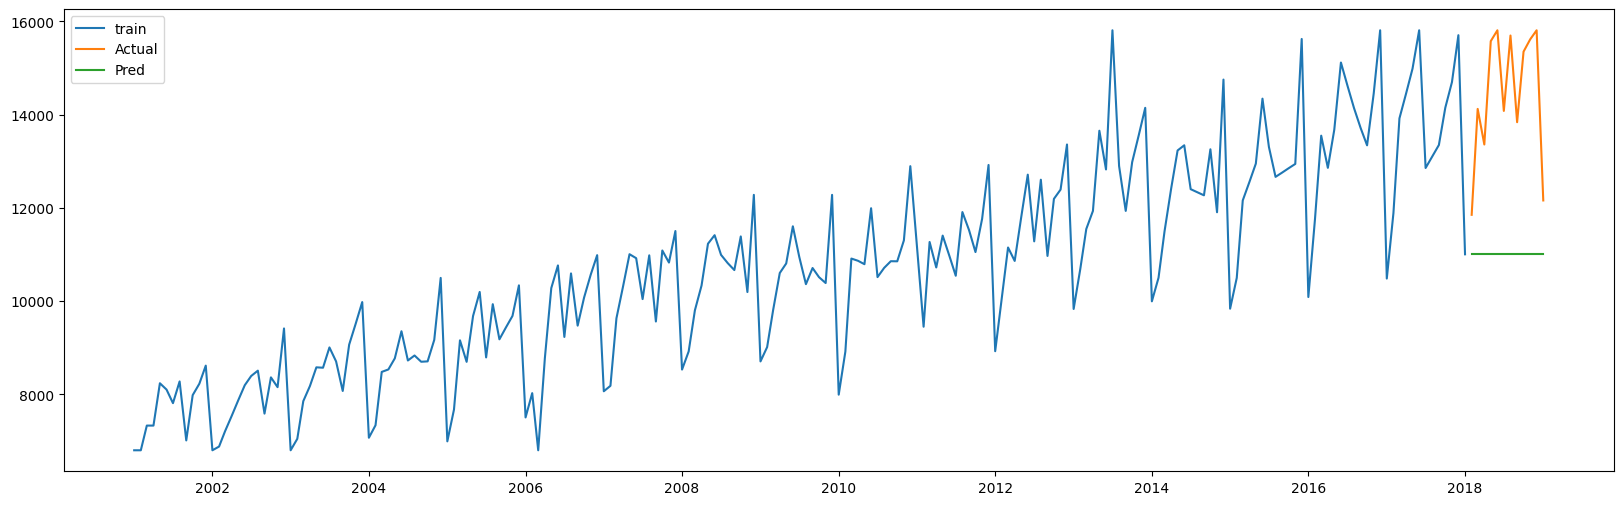

In [ ]:
plt.plot(train_x["Sales"],label="train")
plt.plot(test_x["Sales"],label="Actual")
plt.plot(test_x["pred"],label="Pred")
plt.legend()

In [ ]:
performance(test_x['Sales'], test_x['pred'])

MAE : 3434.233
RMSE : 3697.005
MAPE: 0.23


In [ ]:
test_x["pred"] = 0
for i in test_x.index:
  test_x.loc[i,'pred'] = train_x.loc[i - pd.DateOffset(years=1),'Sales']

/tmp/ipython-input-87-2641147438.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14453.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_x.loc[i,'pred'] = train_x.loc[i - pd.DateOffset(years=1),'Sales']


In [ ]:
test_x

,Sales,pred
DATE,,
2018-02-01,11852.0,11891.0
2018-03-01,14123.0,13921.0
2018-04-01,13360.0,14453.5
2018-05-01,15576.0,14986.0
2018-06-01,15809.4,15809.4
2018-07-01,14080.0,12856.0
2018-08-01,15697.0,13102.5
2018-09-01,13838.0,13349.0
2018-10-01,15351.0,14150.0


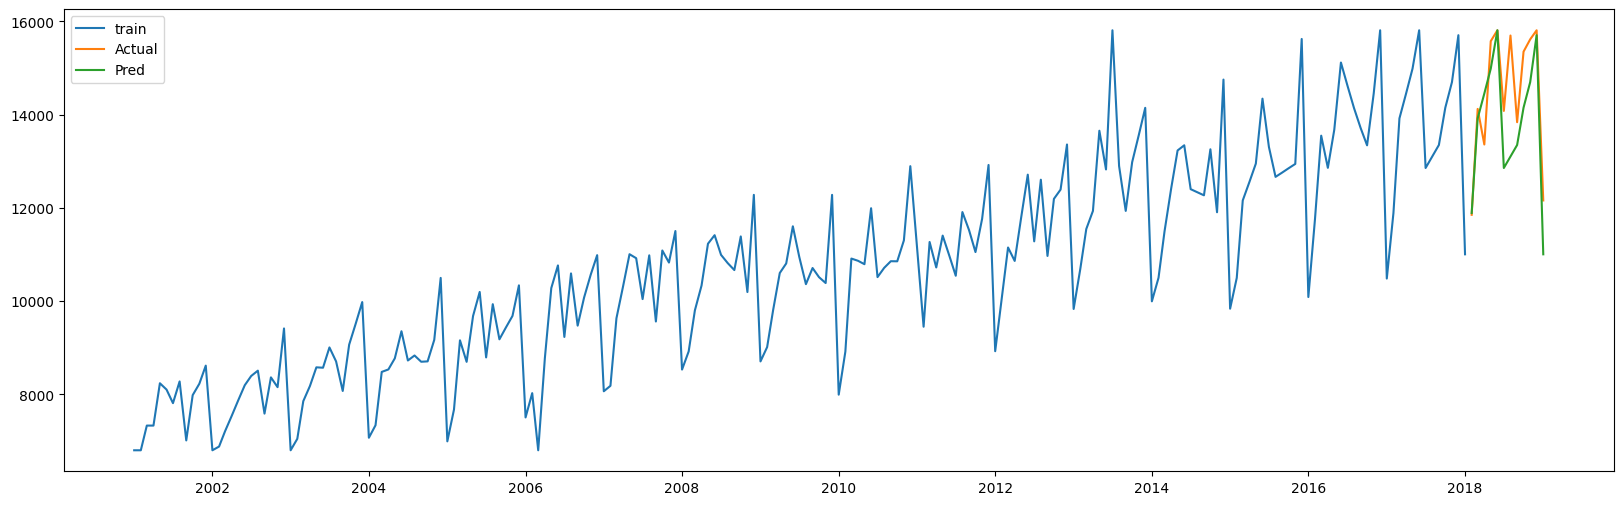

In [ ]:
plt.plot(train_x["Sales"],label="train")
plt.plot(test_x["Sales"],label="Actual")
plt.plot(test_x["pred"],label="Pred")

plt.legend()

In [ ]:
performance(test_x['Sales'], test_x['pred'])

MAE : 800.867
RMSE : 1067.837
MAPE: 0.055


In [ ]:
# Get the slope
y_t = train_x['Sales'][-1]
m = (y_t - train_x['Sales'][0]) / len(train_x)

k = np.linspace(start=0,stop=len(test_x)-1, num=len(test_x))

test_x['pred'] = y_t + m * k


/tmp/ipython-input-91-1178064295.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_t = train_x['Sales'][-1]
/tmp/ipython-input-91-1178064295.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m = (y_t - train_x['Sales'][0]) / len(train_x)


In [ ]:
test_x


,Sales,pred
DATE,,
2018-02-01,11852.0,11005.000000
2018-03-01,14123.0,11025.500293
2018-04-01,13360.0,11046.000585
2018-05-01,15576.0,11066.500878
2018-06-01,15809.4,11087.001171
2018-07-01,14080.0,11107.501463
2018-08-01,15697.0,11128.001756
2018-09-01,13838.0,11148.502049
2018-10-01,15351.0,11169.002341


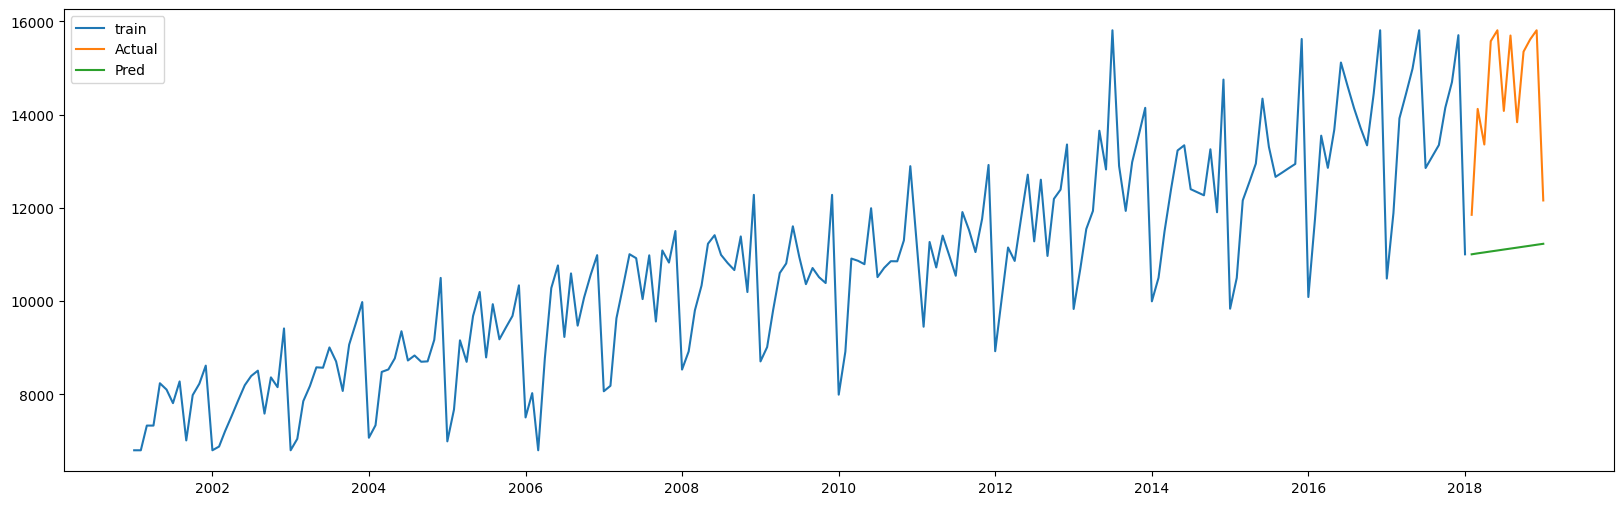

In [ ]:
plt.plot(train_x["Sales"],label="train")
plt.plot(test_x["Sales"],label="Actual")
plt.plot(test_x["pred"],label="Pred")

plt.legend()

In [ ]:
y_t = train_x['Sales'][-2]
m = (y_t - train_x['Sales'][0]) / len(train_x)

k = np.linspace(start=0,stop=len(test_x)-1, num=len(test_x))

test_x['pred'] = y_t + m * k


/tmp/ipython-input-94-2082395286.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_t = train_x['Sales'][-2]
/tmp/ipython-input-94-2082395286.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m = (y_t - train_x['Sales'][0]) / len(train_x)


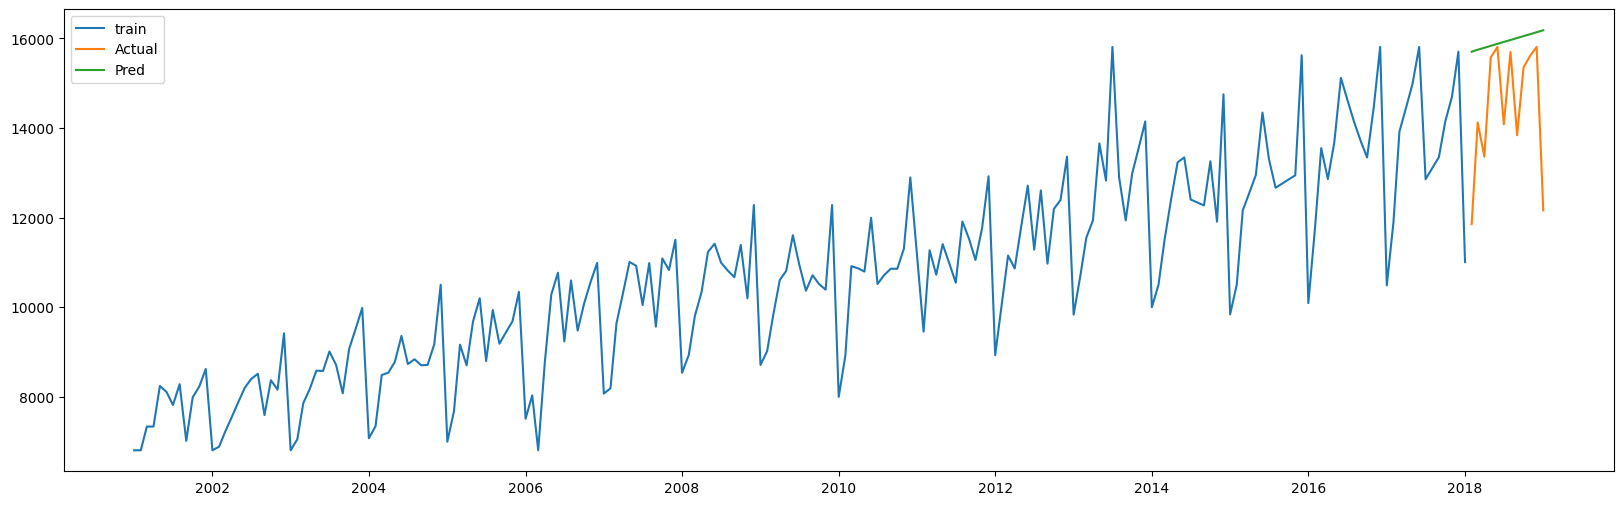

In [ ]:
plt.plot(train_x["Sales"],label="train")
plt.plot(test_x["Sales"],label="Actual")
plt.plot(test_x["pred"],label="Pred")

plt.legend()

In [ ]:
test_x.shape

(12, 2)

In [ ]:
pred_ = train_x.Sales.copy().values

for i in range(12):
    pred_ = np.append(pred_, pred_[-3:].mean()) # MA(6) last 6 months avg.

test_x['pred'] = pred_[-12:] # predictions

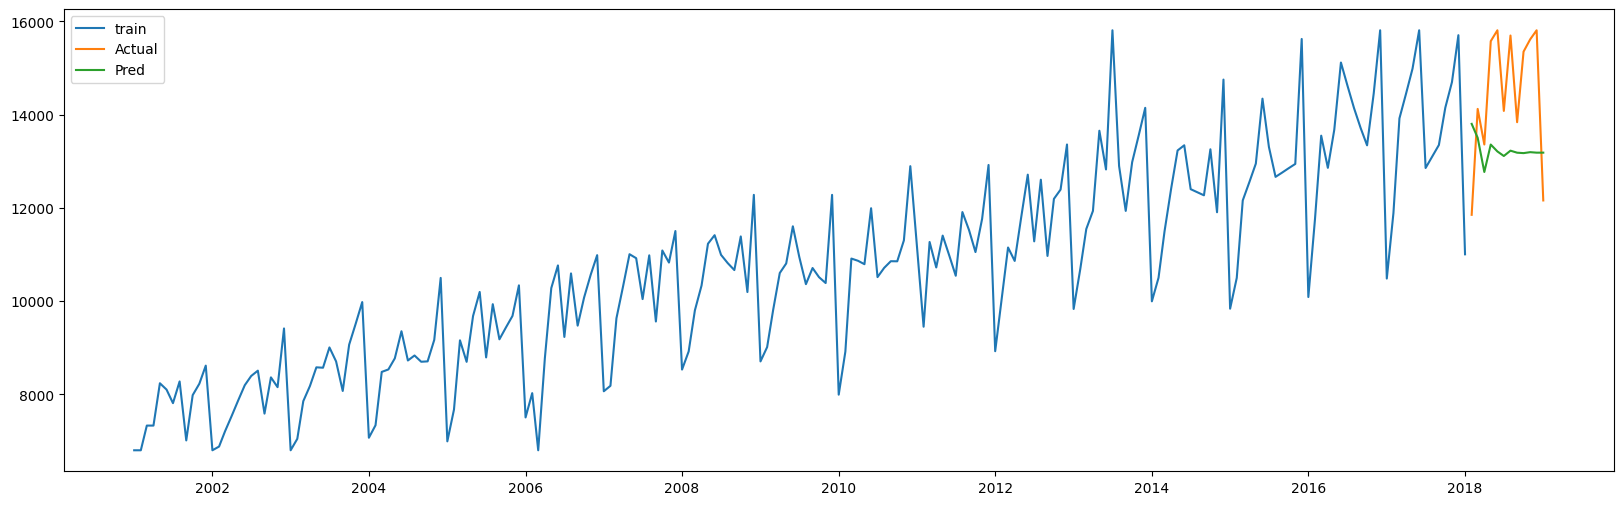

In [ ]:
plt.plot(train_x["Sales"],label="train")
plt.plot(test_x["Sales"],label="Actual")
plt.plot(test_x["pred"],label="Pred")

plt.legend()

In [ ]:
performance(test_x['Sales'], test_x['pred'])

MAE : 1692.467
RMSE : 1875.03
MAPE: 0.115
